<a href="https://colab.research.google.com/github/vadhri/cfd-notebook/blob/main/differencing_schemes/hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The hybrid differencing scheme uses central differencing and upwind differencing schemes. The flow representation would be as below.
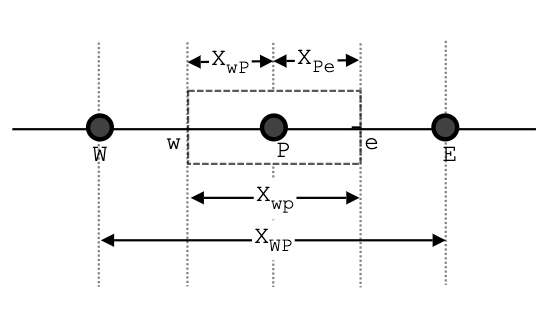

### Discretization of Flux at West Face

#### For pecklet number between -2 and 2

$$
q_w = (ρ \cdot u \cdot \phi)_w - \left( \Gamma \frac{d\phi}{dx} \right)_w
$$

$$
= F_w \phi_w - \Gamma_w \left( \frac{d\phi}{dx} \right)_w
$$

Using central differencing:

$$
\phi_w \approx \frac{\phi_W + \phi_P}{2}
$$

$$
\left( \frac{d\phi}{dx} \right)_w \approx \frac{\phi_P - \phi_W}{\delta x}
$$

Substituting:

$$
q_w = F_w \left( \frac{\phi_W + \phi_P}{2} \right) - \Gamma_w \left( \frac{\phi_P - \phi_W}{\delta x} \right)
$$

Rearranging:

$$
q_w = \left( \frac{F_w}{2} + \frac{\Gamma_w}{\delta x} \right) \phi_W
+ \left( \frac{F_w}{2} - \frac{\Gamma_w}{\delta x} \right) \phi_P
$$

Define diffusion conductance:

$$
D_w = \frac{\Gamma_w}{\delta x}
$$

Then:

$$
q_w = \left( \frac{F_w}{2} + D_w \right) \phi_W
+ \left( \frac{F_w}{2} - D_w \right) \phi_P
$$

Using Peclet number:

$$
Pe_w = \frac{F_w}{D_w}
$$

Final form:

$$
q_w = F_w \left[ \left( \frac{1}{2} + \frac{1}{Pe_w} \right) \phi_W
+ \left( \frac{1}{2} - \frac{1}{Pe_w} \right) \phi_P \right]
$$

#### For peklet number, the values for >2 and >-2 are as below.

$$
q_w = F_w \cdot \phi_W
$$

$$
q_w = F_w \cdot \phi_P
$$

### Node 1

$$
F_e \phi_e - F_w \phi_w = D_e (\phi_E - \phi_P) - D_w (\phi_P - \phi_W)
$$

Upwind scheme:

$$
\phi_w = \phi_A,\quad \phi_e = \phi_P
$$

Substitute:

$$
F_e \phi_P - F_w \phi_A = -D_A (\phi_P - \phi_A)
$$

Rearrange:

$$
(F_e + D_A)\phi_P = F_w \phi_A + D_A \phi_A
$$

Assume:

$$
F_e = F_w = F,\quad D_A = 2D
$$

$$
(F + 2D)\phi_P = (F + 2D)\phi_A
$$

Coefficients:

$$
a_W = 0,\quad a_E = 0
$$

$$
S_u = (2D + F)\phi_A,\quad S_P = -(2D + F)
$$

### Node 5

$$
F_e \phi_e - F_w \phi_w = D_e (\phi_E - \phi_P) - D_w (\phi_P - \phi_W)
$$

Upwind:

$$
\phi_w = \phi_W,\quad \phi_e = \phi_P
$$

Boundary at east:

$$
\phi_E = \phi_B
$$

Substitute:

$$
F \phi_P - F \phi_W = D_B (\phi_B - \phi_P)
$$

Assume:

$$
D_B = 2D,\quad F = \text{const}
$$

$$
F \phi_P - F \phi_W = 2D (\phi_B - \phi_P)
$$

Rearrange:

$$
(2D + F)\phi_P = 2D \phi_B + F \phi_W
$$

Coefficients:

$$
a_P = 2D + F,\quad a_E = 0,\quad a_W = F
$$

$$
S_P = -2D,\quad S_u = 2D \phi_B
$$

In [46]:
"""
Calculates the analytical solution for the 1-D steady-state convection-diffusion equation.

Args:
    x (float or np.array): Position(s) at which to calculate phi.
    u_val (float): Velocity.
    L_val (float): Length of the domain.
    rho_val (float): Density.
    Gamma_val (float): Diffusion coefficient.

Returns:
    float or np.array: The analytical solution for phi at position x.
"""
def phi_analytical(x, u_val, L_val, rho_val, Gamma_val):
    Pe = (rho_val * u_val * L_val) / Gamma_val
    phi_x = (np.exp(Pe * x / L_val) - np.exp(Pe)) / (1 - np.exp(Pe))
    return phi_x


The logic below determines whether to use Upwind or Central Differencing based on the Peclet number, calculates system coefficients, forms a matrix, and then solves the linear system to find the phi values.

In [88]:
|import numpy as np

# Function to calcuate pecklet number given u, rho, gamma and del x
rho = 1
u_velocity = 2.5
Gamma = 0.1
dx = 0.02
L = 1

F = rho*u_velocity
D = Gamma / dx

phi_a = 1
phi_b = 0

N = 50

# matrix with ap, aw, ae values
print ("pecklet number = ", F/D)
if F/D > 2:
  aw = [0]
  for i in range(N-1):
    aw.append(F)

  ae = np.array([0]*N)

  # Define sp explicitly based on boundary conditions
  sp = np.zeros(N)
  sp[0] = -(2*D + F)
  sp[N-1] = -2*D

  # Corrected su calculation
  su = np.array([(2*D+F)*phi_a] + [0]*(N-2) + [2*D*phi_b])
else:
  print ("Central differencing method -->")
  aw = [0]
  for i in range(N-1):
    aw.append(D+(F/2))

  ae = np.array([D-(F/2)]*N)
  ae[-1] = 0

  # Define sp explicitly based on boundary conditions
  sp = np.zeros(N)
  sp[0] = -((2*D)+F)
  sp[N-1] = -((2*D)-F)

  # Corrected su calculation
  su = np.array([(2*D+F)*phi_a] + [0]*(N-2) + [(2*D-F)*phi_b])
ap = np.array(aw) + ae - sp # Ensure aw is also a numpy array for element-wise operations

#2d emty matrix NxN
matrix = np.zeros((N,N))

for i in range(N):
  if i-1 >= 0:
    matrix[i][i-1] = -aw[i]
  matrix[i][i] = ap[i]
  if i + 1 < N:
    matrix[i][i+1] = -ae[i]

print(matrix)

# solve matrix * phi = Su
phi = np.linalg.solve(matrix,su)

solution_hybrid = phi

pecklet number =  0.5
Central differencing method -->
[[16.25 -3.75  0.   ...  0.    0.    0.  ]
 [-6.25 10.   -3.75 ...  0.    0.    0.  ]
 [ 0.   -6.25 10.   ...  0.    0.    0.  ]
 ...
 [ 0.    0.    0.   ... 10.   -3.75  0.  ]
 [ 0.    0.    0.   ... -6.25 10.   -3.75]
 [ 0.    0.    0.   ...  0.   -6.25 13.75]]


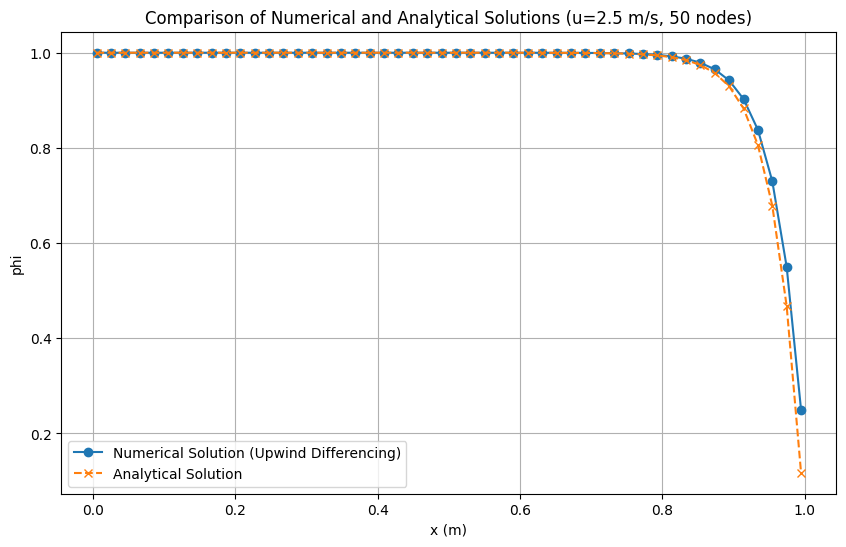

In [89]:

import matplotlib.pyplot as plt
num_nodes = N

# Calculate the effective grid spacing for plotting purposes
dx_effective = dx / 2
# Generate x-coordinates for the numerical solution (nodes) as cell centers
x_numerical = np.linspace(dx_effective / 2, L - dx_effective / 2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, u_velocity, L, rho, Gamma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, solution_hybrid, 'o-', label='Numerical Solution (Upwind Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title(f'Comparison of Numerical and Analytical Solutions (u={u_velocity} m/s, {num_nodes} nodes)')
plt.grid(True)
plt.legend()
plt.show()
